In [ ]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
print(T.ndim,"\n",T.shape)
print()
# 2. T + T
print(T+T)
print()
# 3. Transpose (print .T.shape) and reshape to (2, 6)
print(T.T.shape,"\n",T.reshape(2,6))

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
2 
 (3, 4)

[[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]

(4, 3) 
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [ ]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    print(la.norm(u,1))
    print(la.norm(u))
    # 2. cosine similarity of u and v
    cos=np.dot(u,v)/(la.norm(u)*la.norm(v))
    print(cos)
    pass

# 3. Most similar pair = ?   (write your answer here)
# pair 1 since cosine value is max that is closest to 1

2.0
1.4142135623730951
0.9999999999999998
6.0
3.7416573867739413
0.7142857142857143
2.0
2.0
0.0


In [ ]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
print(la.inv(M))
print(np.trace(M))
# 2. M @ inv(M) == I ?
I=np.eye(2)
print(np.allclose(M @la.inv(M),I))

# 3. Is M symmetric? Is P orthogonal?
print("M is symmetric ",np.allclose(M,M.T))
print("P is orthogonal ",np.allclose(P.T@P,I))


[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
7.0
True
M is symmetric  True
P is orthogonal  True


scaled= [[0.  2.  1. ]
 [0.  0.  0.5]]
rotated= [[ 0.     0.707 -0.354]
 [ 0.     0.707  1.061]]


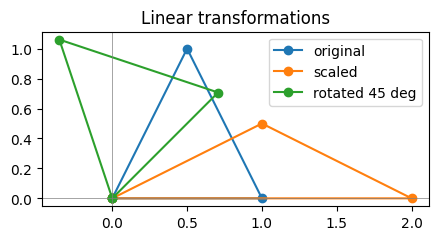

In [ ]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
S=np.array([[2.0, 0.0],
            [0.0, 0.5]])
Scaled=S @ tri
print("scaled=",Scaled)
# 2. Rotation matrix (45 degrees)
t=np.radians(45)
R=np.array([[np.cos(t), -np.sin(t)],
            [np.sin(t), np.cos(t)]])
Rotated=R @ tri
print("rotated=",Rotated)

# 3. Apply both and plot original vs transformed
# YOUR CODE HERE
def close_loop(pts):

    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(tri),  marker='o', label='original')
ax.plot(*close_loop(Scaled),  marker='o', label='scaled')
ax.plot(*close_loop(Rotated), marker='o', label='rotated 45 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

In [ ]:
C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
vals, vecs = la.eig(C)
print('Eigenvalues  :', vals)
print('Eigenvectors :', vecs)
# 2. print eigenvalues
print("\n",vals)
# 3. verify A v = lambda v for the first eigenvector
for i in range(len(vals)):
    v = vecs[:, i]
    lhs = C @ v
    rhs = vals[i] * v
    print(f'lambda={vals[i]:.1f}  C v == lambda v ?', np.allclose(lhs, rhs))

Eigenvalues  : [5. 2.]
Eigenvectors : [[ 0.707 -0.447]
 [ 0.707  0.894]]

 [5. 2.]
lambda=5.0  C v == lambda v ? True
lambda=2.0  C v == lambda v ? True


In [ ]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
print(la.solve(A2,b2))
# 2. Rank of A2
print(la.matrix_rank(A2))
# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
def cosine(a, b):
  return a @ b / (la.norm(a) * la.norm(b))

print('cosine(cat, dog):', round(cosine(cat, dog), 3))   # high
print('cosine(cat, car):', round(cosine(cat, car), 3))   # low

[1. 2.]
2
cosine(cat, dog): 0.995
cosine(cat, car): 0.293
